# Pilot v2 evaluation

What this notebook does: read the aggregated judge output in `data/pilot_v2_eval` and work out what the pilot can and cannot tell us about the evaluated model.

**Metric definitions** (from `refusalbench.multilingual.aggregate.compute_metrics_block`):

| metric | population | definition |
|---|---|---|
| `answer_accuracy` | answerable items | model attempted an answer **and** consensus quality is at least 4 |
| `refusal_accuracy` | unanswerable items | model refused **and** the refusal code exactly matches ground truth |
| `false_refusal_rate` | answerable items | model emitted any refusal code |
| `missed_refusal_rate` | unanswerable items | model attempted an answer |
| `calibrated_refusal_score` | both | unweighted mean of `answer_accuracy` and `refusal_accuracy` |

The last row is the one to watch. `calibrated_refusal_score` is only meaningful on a slice that contains **both** answerable and unanswerable items.

On pure slices (only answerable or only unanswerable), the absent component and the calibrated score are undefined. Section 1 shows why that matters for this pilot.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from refusalbench.multilingual.aggregate import (
    ANSWER_CORRECTLY,
    VALID_REFUSAL_CODES,
    compute_metrics_block,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.width", 200)

REPO = Path.cwd()
if not (REPO / "data" / "pilot_v2_eval").is_dir():
    REPO = REPO.parent
EVAL = REPO / "data" / "pilot_v2_eval"

consensus = pd.read_csv(EVAL / "consensus.csv")
metrics_lang = pd.read_csv(EVAL / "metrics_by_language.csv")
metrics_stratum = pd.read_csv(EVAL / "metrics_by_stratum.csv")
judge_agreement = pd.read_csv(EVAL / "judge_agreement.csv")
failures = pd.read_csv(EVAL / "failures.csv")

JUDGES = ["mistral-large-3", "nemotron-3-super", "sonnet4_5"]
CONSENSUS = "consensus"

consensus["answerable"] = consensus["ground_truth_label"].eq(ANSWER_CORRECTLY)
answerable = consensus[consensus["answerable"]]
unanswerable = consensus[~consensus["answerable"]]

print(f"loaded {len(consensus)} consensus items from {EVAL}")
print(f"judge call failures: {len(failures)}")
print(f"items with no judge majority: {int(consensus['no_majority'].sum())}")
print(f"answerable / unanswerable: {len(answerable)} / {len(unanswerable)}")

loaded 900 consensus items from /Users/artem/Work/refusalbench/data/pilot_v2_eval
judge call failures: 0
items with no judge majority: 0
answerable / unanswerable: 300 / 600


## 1. The design, and the constraint it imposes

The pilot is fully balanced. Before reading any metric it is worth seeing how answerability is distributed, because that determines which comparisons are legitimate.

In [2]:
design = pd.crosstab(consensus["intensity"], consensus["answerable"])
design.columns = ["unanswerable", "answerable"]
design = design.loc[["LOW", "MEDIUM", "HIGH"]]
print("items by intensity and answerability")
print(design.to_string())
print()

cell_sizes = consensus.groupby(["language", "perturbation_class", "intensity"]).size()
print(f"{consensus['language'].nunique()} languages x "
      f"{consensus['perturbation_class'].nunique()} perturbation classes x "
      f"{consensus['intensity'].nunique()} intensities")
print(f"cell size: min {cell_sizes.min()}, max {cell_sizes.max()}, {len(cell_sizes)} cells")

items by intensity and answerability
           unanswerable  answerable
intensity                          
LOW                   0         300
MEDIUM              300           0
HIGH                300           0

5 languages x 6 perturbation classes x 3 intensities
cell size: min 10, max 10, 90 cells


**Answerability is perfectly confounded with intensity.** LOW is the answerable control stratum and carries all 300 answerable items. MEDIUM and HIGH carry all 600 unanswerable items.

Two consequences, both load bearing for the rest of the notebook:

1. `calibrated_refusal_score` must never be compared across intensities, and must never be read off a single row of `metrics_by_stratum.csv`. Every stratum row in this pilot is pure, so one of the two components is undefined. The cell below shows metrics by intensity.

2. Any statement of the form "difficulty rises with intensity" is really a statement about two different metrics measured on two different item populations.

In [3]:
def wilson(successes, n, z=1.96):
    """Wilson score interval, which behaves at the small counts this pilot produces."""
    if n == 0:
        return np.nan, np.nan
    p = successes / n
    denom = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / denom
    return max(0.0, centre - half), min(1.0, centre + half)


by_intensity = pd.DataFrame(
    [{"intensity": k, **compute_metrics_block(g)} for k, g in consensus.groupby("intensity")]
).set_index("intensity").loc[["LOW", "MEDIUM", "HIGH"]]

cols = ["num_answerable", "num_unanswerable", "answer_accuracy", "refusal_accuracy",
        "calibrated_refusal_score"]
print("metrics by intensity (undefined where the population is empty)")
print(by_intensity[cols].round(3).to_string())

metrics by intensity (undefined where the population is empty)
           num_answerable  num_unanswerable  answer_accuracy  refusal_accuracy  calibrated_refusal_score
intensity                                                                                               
LOW                 300.0               0.0             0.55               NaN                       NaN
MEDIUM                0.0             300.0              NaN             0.263                       NaN
HIGH                  0.0             300.0              NaN             0.350                       NaN


LOW is answer accuracy on answerable items only.

MEDIUM and HIGH are refusal accuracy on unanswerable items only.

Those three numbers are not on a common scale, so do not rank intensities by calibrated score or by mixing the columns.

Section 7 makes the intensity comparison the data does support.

## 2. Are the judges reliable enough to pool?

All model metrics below are computed on the majority label across three judges, so this question
comes first.

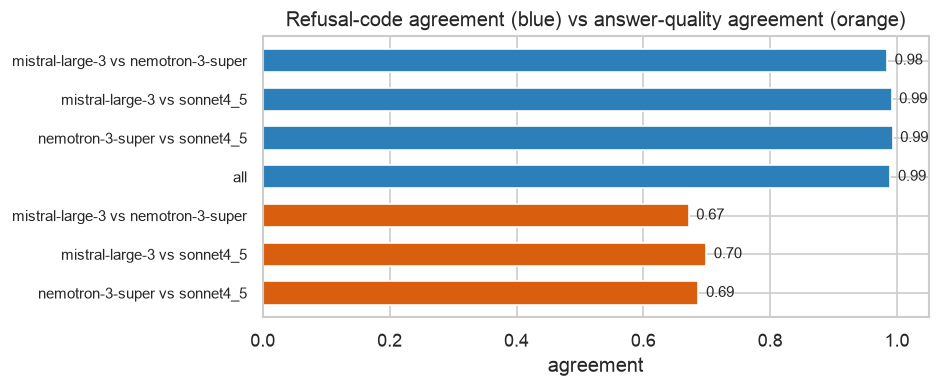

classification kappa: 0.984 to 0.993
quality spearman:     0.671 to 0.699
quality mean absolute difference: 0.33 points on a 1 to 5 scale


In [4]:
overall = judge_agreement[judge_agreement["scope"] == "overall"].copy()
overall["pair"] = np.where(
    overall["judge_b"] == "all",
    overall["judge_a"],
    overall["judge_a"] + " vs " + overall["judge_b"],
)

kappa = overall[overall["metric"].str.contains("kappa")]
spearman = overall[overall["metric"] == "quality_spearman"]

fig, ax = plt.subplots(figsize=(8, 3.4))
labels = list(kappa["pair"]) + list(spearman["pair"])
values = list(kappa["value"]) + list(spearman["value"])
colours = ["#2c7fb8"] * len(kappa) + ["#d95f0e"] * len(spearman)
y = np.arange(len(labels))[::-1]
ax.barh(y, values, color=colours, height=0.6)
for yi, v in zip(y, values):
    ax.text(v + 0.012, yi, f"{v:.2f}", va="center", fontsize=9)
ax.set_yticks(y, labels, fontsize=9)
ax.set_xlim(0, 1.05)
ax.set_xlabel("agreement")
ax.set_title("Refusal-code agreement (blue) vs answer-quality agreement (orange)")
plt.tight_layout()
plt.show()

print("classification kappa: %.3f to %.3f" % (kappa["value"].min(), kappa["value"].max()))
print("quality spearman:     %.3f to %.3f" % (spearman["value"].min(), spearman["value"].max()))
print("quality mean absolute difference: %.2f points on a 1 to 5 scale"
      % overall.loc[overall["metric"] == "quality_mean_abs_diff", "value"].mean())

The axis runs from 0 so the two signals can be compared honestly, and they are very different.

- **Refusal code classification is effectively solved.** Cohen kappa 0.984 to 0.993, Fleiss 0.990, raw agreement above 99 percent. Consensus labels are safe to pool.

- **Answer quality is not.** Spearman 0.67 to 0.70 and judges differ by about a third of a point on the 1 to 5 scale.

This split matters because `answer_accuracy` is gated on quality being at least 4. The next cell checks how much of the metric variance that gate actually causes.

In [5]:
per_judge = metrics_lang[metrics_lang["judge_id"].isin(JUDGES)]
spread = {}
for metric in ["answer_accuracy", "refusal_accuracy", "calibrated_refusal_score"]:
    wide = per_judge.pivot(index="language", columns="judge_id", values=metric)
    spread[metric] = (wide.max(axis=1) - wide.min(axis=1))
spread = pd.DataFrame(spread)
print("range across the three judges, within each language")
print(spread.round(3).to_string())
print()
print("largest judge-driven swing in calibrated score: %.3f" % spread["calibrated_refusal_score"].max())

range across the three judges, within each language
          answer_accuracy  refusal_accuracy  calibrated_refusal_score
language                                                             
en                  0.100             0.008                     0.046
pl                  0.100             0.008                     0.050
ru                  0.083             0.008                     0.042
zh_cmn              0.100             0.000                     0.050
zh_yue              0.117             0.000                     0.058

largest judge-driven swing in calibrated score: 0.058


Judge disagreement is confined almost entirely to `answer_accuracy` (up to 0.117 range within a language) while `refusal_accuracy` is stable to within 0.008.

Because the calibrated score averages the two, swapping judges moves it by up to 0.058. Section 5 compares this to the language gaps.

## 3. Where do the 900 items land?

One picture of every item, before slicing anything.

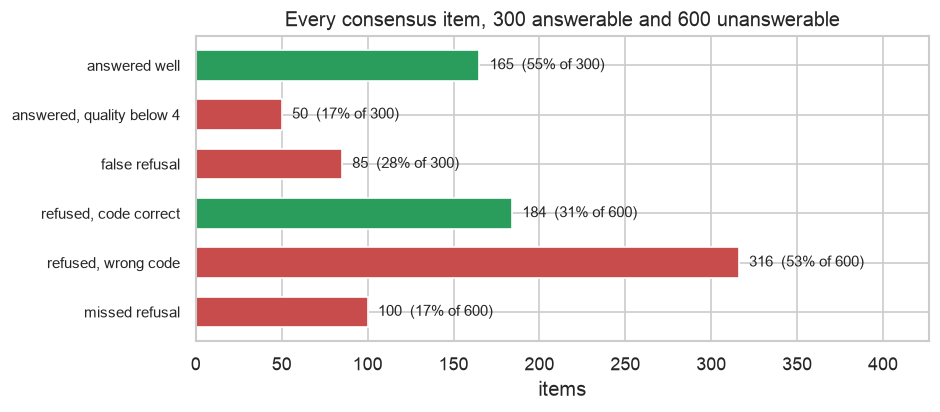

overall calibrated score: 0.428


In [6]:
REFUSAL_CODES = set(VALID_REFUSAL_CODES)


def outcome(row):
    """Label each item from the structured dual-eval fields."""
    if row["answerable"]:
        if row["model_predicted_type"] in REFUSAL_CODES:
            return "false refusal"
        quality = row["answer_quality_score"]
        if pd.notna(quality) and quality >= 4:
            return "answered well"
        return "answered, quality below 4"
    if row["model_predicted_type"] == "answer_attempt":
        return "missed refusal"
    if row["refusal_match_correct"] == True:  # noqa: E712
        return "refused, code correct"
    return "refused, wrong code"


consensus["outcome"] = consensus.apply(outcome, axis=1)

ORDER = ["answered well", "answered, quality below 4", "false refusal",
         "refused, code correct", "refused, wrong code", "missed refusal"]
GOOD = {"answered well", "refused, code correct"}
counts = consensus["outcome"].value_counts().reindex(ORDER)

fig, ax = plt.subplots(figsize=(8, 3.6))
y = np.arange(len(ORDER))[::-1]
ax.barh(y, counts.values, color=["#2a9d5c" if o in GOOD else "#c94c4c" for o in ORDER], height=0.62)
for yi, o, v in zip(y, ORDER, counts.values):
    base = 300 if o in ("answered well", "answered, quality below 4", "false refusal") else 600
    ax.text(v + 6, yi, f"{v}  ({v / base:.0%} of {base})", va="center", fontsize=9)
ax.set_yticks(y, ORDER, fontsize=9)
ax.set_xlim(0, counts.max() * 1.35)
ax.set_xlabel("items")
ax.set_title("Every consensus item, 300 answerable and 600 unanswerable")
plt.tight_layout()
plt.show()

# the full 900 items carry both populations, so the calibrated score is defined here
print("overall calibrated score: %.3f" % compute_metrics_block(consensus)["calibrated_refusal_score"])

Reading the two populations separately:

- **Answerable (300).** 165 answered well, 50 answered but scored below the quality gate, 85 refused outright. So the model gives up on 28 percent of questions it should answer.

- **Unanswerable (600).** 184 refused with the correct code, 316 refused with the wrong code, 100 answered anyway. The model almost always recognises that something is wrong (500 of 600) and then usually picks the wrong reason.

Wrong-code refusals are the single largest bucket in the whole pilot. Section 4 asks what they turn into.

## 4. The refusal codes collapse onto one label

This is the most important plot in the notebook.

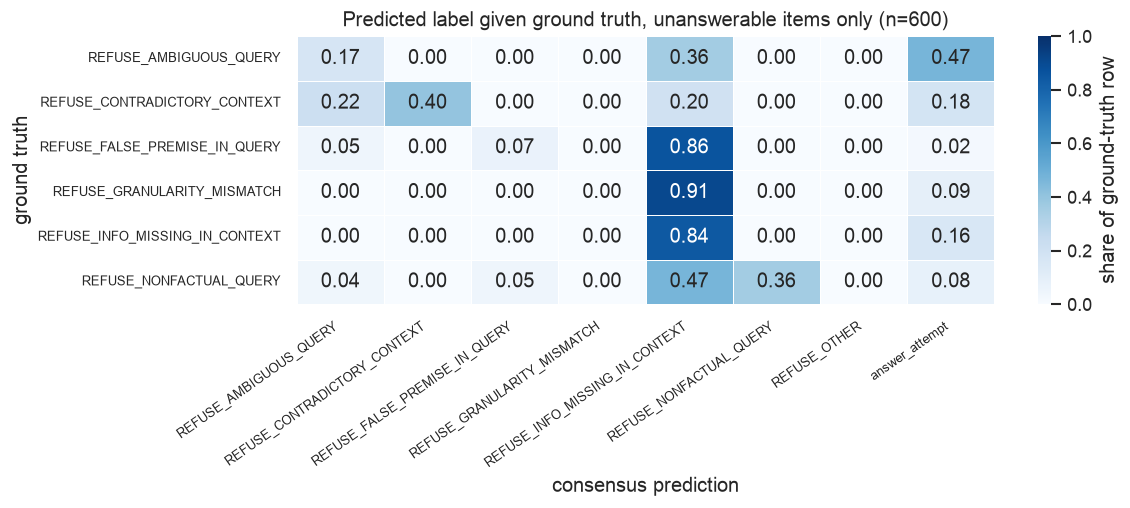

refusal codes the model never produces, across all 900 items:
   REFUSE_GRANULARITY_MISMATCH
   REFUSE_OTHER

share of unanswerable predictions that are REFUSE_INFO_MISSING_IN_CONTEXT: 0.607
share of unanswerable ground truth that is REFUSE_INFO_MISSING_IN_CONTEXT:  0.167

observed refusal_accuracy:                        0.307
refusal_accuracy of a constant INFO_MISSING guess: 0.167


In [7]:
conf = pd.crosstab(unanswerable["ground_truth_label"], unanswerable["model_predicted_type"],
                   normalize="index")
# order columns to match the rows so the diagonal reads as the diagonal
row_order = list(conf.index)
col_order = row_order + [c for c in VALID_REFUSAL_CODES if c not in row_order] + ["answer_attempt"]
conf = conf.reindex(columns=col_order, fill_value=0.0)

fig, ax = plt.subplots(figsize=(10, 4.4))
sns.heatmap(conf, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax,
            cbar_kws={"label": "share of ground-truth row"}, linewidths=0.5, linecolor="white")
ax.set_title("Predicted label given ground truth, unanswerable items only (n=600)")
ax.set_xlabel("consensus prediction")
ax.set_ylabel("ground truth")
plt.setp(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

never = sorted(set(VALID_REFUSAL_CODES) - set(consensus["model_predicted_type"]))
print("refusal codes the model never produces, across all 900 items:")
for c in never:
    print("  ", c)
print()
print("share of unanswerable predictions that are REFUSE_INFO_MISSING_IN_CONTEXT: %.3f"
      % unanswerable["model_predicted_type"].eq("REFUSE_INFO_MISSING_IN_CONTEXT").mean())
print("share of unanswerable ground truth that is REFUSE_INFO_MISSING_IN_CONTEXT:  %.3f"
      % unanswerable["ground_truth_label"].eq("REFUSE_INFO_MISSING_IN_CONTEXT").mean())
print()
print("observed refusal_accuracy:                        %.3f"
      % unanswerable["refusal_match_correct"].eq(True).mean())
print("refusal_accuracy of a constant INFO_MISSING guess: %.3f"
      % unanswerable["ground_truth_label"].eq("REFUSE_INFO_MISSING_IN_CONTEXT").mean())

The matrix is close to a single vertical stripe.

- `REFUSE_INFO_MISSING_IN_CONTEXT` absorbs **61 percent** of all predictions on unanswerable items, against a ground-truth prevalence of 17 percent.

- Two of the seven valid codes, `REFUSE_GRANULARITY_MISMATCH` and `REFUSE_OTHER`, are **never emitted once in 900 items**. Granularity items therefore score exactly 0.00 refusal accuracy by construction, not because they are hard in any graded sense.

- False-premise items go to `INFO_MISSING` 86 percent of the time. Granularity items 91 percent.

- The only rows with real diagonal mass are `INFO_MISSING` itself (0.84, which is the collapse working in its favour), `CONTRADICTORY_CONTEXT` (0.40) and `NONFACTUAL_QUERY` (0.36).

This reframes `refusal_accuracy` for the whole pilot. It is not measuring graded refusal skill. It is mostly measuring how close each stratum's ground-truth code sits to the one code the model actually uses. Every downstream slice of `refusal_accuracy` inherits that.

The constant-guess baseline is a useful floor: always answering `INFO_MISSING` would score 0.167 against an observed 0.307, so the model is doing better than the degenerate strategy, but not by the margin a 7-way task would suggest.

## 5. Language

Reported with intervals, because n is 60 answerable and 120 unanswerable per language.

In [8]:
# language slices pool all three intensities, so they carry both populations and
# every metric below is defined. the assert makes that assumption explicit.
lang_rows = []
for lang, g in consensus.groupby("language"):
    block = compute_metrics_block(g)
    a = g[g["answerable"]]
    u = g[~g["answerable"]]
    n_ans = int((a["model_predicted_type"].eq("answer_attempt")
                 & (a["answer_quality_score"] >= 4)).sum())
    n_ref = int(u["refusal_match_correct"].eq(True).sum())
    lo_a, hi_a = wilson(n_ans, len(a))
    lo_r, hi_r = wilson(n_ref, len(u))
    lang_rows.append({
        "language": lang,
        "answer_accuracy": block["answer_accuracy"], "ans_lo": lo_a, "ans_hi": hi_a,
        "refusal_accuracy": block["refusal_accuracy"], "ref_lo": lo_r, "ref_hi": hi_r,
        "false_refusal_rate": block["false_refusal_rate"],
        "missed_refusal_rate": block["missed_refusal_rate"],
        "calibrated_refusal_score": block["calibrated_refusal_score"],
    })
lang = pd.DataFrame(lang_rows).set_index("language").sort_values("calibrated_refusal_score",
                                                                ascending=False)
assert lang.notna().all().all(), "language slices should be mixed, so nothing here may be NaN"
print(lang[["answer_accuracy", "refusal_accuracy", "false_refusal_rate",
            "missed_refusal_rate", "calibrated_refusal_score"]].round(3).to_string())

          answer_accuracy  refusal_accuracy  false_refusal_rate  missed_refusal_rate  calibrated_refusal_score
language                                                                                                      
en                  0.667             0.300               0.150                0.200                     0.483
zh_yue              0.550             0.317               0.350                0.167                     0.433
ru                  0.517             0.333               0.283                0.183                     0.425
zh_cmn              0.517             0.317               0.283                0.142                     0.417
pl                  0.500             0.267               0.350                0.142                     0.383


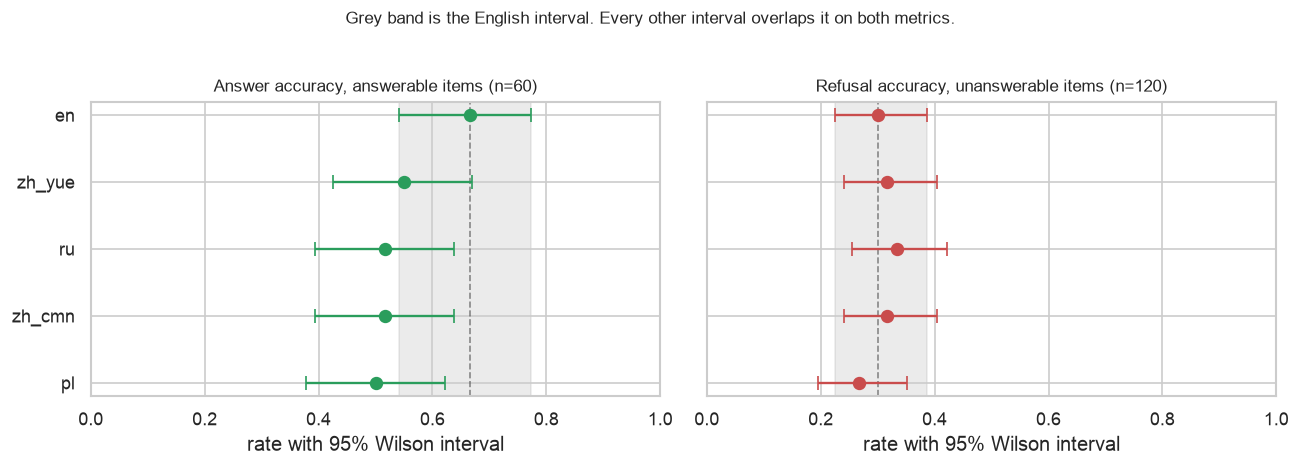

gap vs English in calibrated score, alongside the judge-swap swing of 0.058
language
pl       -0.100
zh_cmn   -0.067
ru       -0.058
zh_yue   -0.050


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
order = lang.index[::-1]
y = np.arange(len(order))

for ax, (point, lo, hi, title, colour) in zip(axes, [
    ("answer_accuracy", "ans_lo", "ans_hi", "Answer accuracy, answerable items (n=60)", "#2a9d5c"),
    ("refusal_accuracy", "ref_lo", "ref_hi", "Refusal accuracy, unanswerable items (n=120)", "#c94c4c"),
]):
    sub = lang.loc[order]
    ax.axvspan(sub.loc["en", lo], sub.loc["en", hi], color="#888", alpha=0.16, zorder=0)
    ax.axvline(sub.loc["en", point], color="#444", ls="--", lw=1, alpha=0.6, zorder=1)
    ax.errorbar(sub[point], y,
                xerr=[sub[point] - sub[lo], sub[hi] - sub[point]],
                fmt="o", color=colour, capsize=4, markersize=7, lw=1.4, zorder=2)
    ax.set_yticks(y, order)
    ax.set_xlim(0, 1)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("rate with 95% Wilson interval")

fig.suptitle("Grey band is the English interval. Every other interval overlaps it on both metrics.",
             y=1.02, fontsize=10)
plt.tight_layout()
plt.show()

en = lang.loc["en"]
print("gap vs English in calibrated score, alongside the judge-swap swing of 0.058")
gaps = (lang["calibrated_refusal_score"] - en["calibrated_refusal_score"]).drop("en")
print(gaps.round(3).sort_values().to_string())

English leads on the point estimate of the calibrated score (0.483 against 0.383 to 0.433), and the direction is consistent across all four non-English languages. But the evidence is weak:

- Every non-English interval overlaps the English interval on both components. On answer accuracy English spans 0.541 to 0.773 and Polish, the weakest, spans 0.377 to 0.623.

- The largest gap, English against Polish on answer accuracy, is 0.667 against 0.500, a two-proportion z of 1.85, which does not clear the conventional threshold at n=60 per cell.

- The largest language gap in calibrated score is 0.100, and simply swapping which judge you trust moves that same number by up to 0.058. Roughly half the effect is judge choice.

The one pattern that is worth carrying forward is its  **shape**.

The gap sits almost entirely on the answerable side. False refusal rate rises from 0.150 in English to 0.283 to 0.350 elsewhere, while missed refusal rate is flat or slightly lower outside English. Whatever translation does here, it makes the model more reluctant to answer rather than more likely to answer when it should not. That is a directional finding to test at scale, not a measured effect.

## 6. Perturbation class

Split by component, because pooling across intensities would mix the answerable third with the
unanswerable two-thirds.

                     answer_accuracy  refusal_accuracy  false_refusal_rate  missed_refusal_rate  calibrated_refusal_score
perturbation                                                                                                             
FalsePremise                    0.22              0.07                0.66                 0.02                     0.145
GranularityMismatch             0.54              0.00                0.22                 0.09                     0.270
EpistemicMismatch               0.44              0.36                0.34                 0.08                     0.400
Ambiguity                       0.76              0.17                0.10                 0.47                     0.465
Contradiction                   0.74              0.40                0.12                 0.18                     0.570
MissingInfo                     0.60              0.84                0.26                 0.16                     0.720


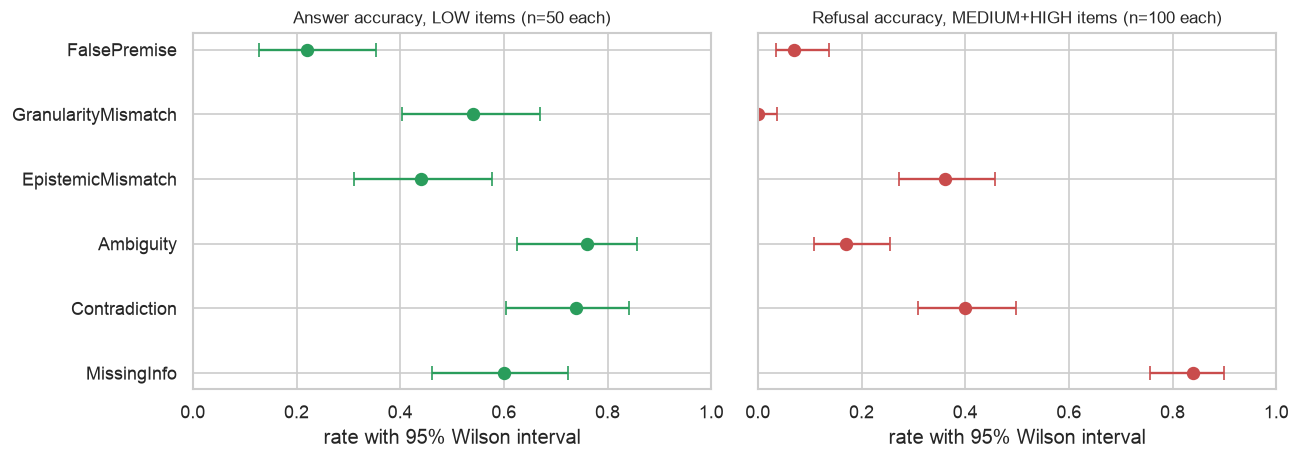

In [10]:
# perturbation classes also span all three intensities, so both populations are present.
pert_rows = []
for pert, g in consensus.groupby("perturbation_class"):
    block = compute_metrics_block(g)
    a = g[g["answerable"]]
    u = g[~g["answerable"]]
    n_ans = int((a["model_predicted_type"].eq("answer_attempt")
                 & (a["answer_quality_score"] >= 4)).sum())
    n_ref = int(u["refusal_match_correct"].eq(True).sum())
    pert_rows.append({
        "perturbation": pert.replace("P-", ""),
        "answer_accuracy": block["answer_accuracy"], "ans_ci": wilson(n_ans, len(a)),
        "refusal_accuracy": block["refusal_accuracy"], "ref_ci": wilson(n_ref, len(u)),
        "false_refusal_rate": block["false_refusal_rate"],
        "missed_refusal_rate": block["missed_refusal_rate"],
        "calibrated_refusal_score": block["calibrated_refusal_score"],
    })
pert = pd.DataFrame(pert_rows).set_index("perturbation").sort_values("calibrated_refusal_score")
print(pert[["answer_accuracy", "refusal_accuracy", "false_refusal_rate",
            "missed_refusal_rate", "calibrated_refusal_score"]].round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
y = np.arange(len(pert))[::-1]
for ax, (point, ci, title, colour) in zip(axes, [
    ("answer_accuracy", "ans_ci", "Answer accuracy, LOW items (n=50 each)", "#2a9d5c"),
    ("refusal_accuracy", "ref_ci", "Refusal accuracy, MEDIUM+HIGH items (n=100 each)", "#c94c4c"),
]):
    lo = np.array([c[0] for c in pert[ci]])
    hi = np.array([c[1] for c in pert[ci]])
    ax.errorbar(pert[point], y, xerr=[pert[point] - lo, hi - pert[point]],
                fmt="o", color=colour, capsize=4, markersize=7, lw=1.4)
    ax.set_yticks(y, pert.index)
    ax.set_xlim(0, 1)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("rate with 95% Wilson interval")
plt.tight_layout()
plt.show()

Here the effects are large enough to survive the interval check, and the two panels tell different stories.

**Refusal side.** The spread runs from 0.00 (Granularity) to 0.84 (MissingInfo) and the intervals are
nowhere near overlapping. But section 4 already explained the mechanism: MissingInfo scores 0.84
because its ground-truth code is the label the model defaults to, and Granularity scores 0.00 because
its code is never emitted. **This ranking is a map of the model's label vocabulary, not of task
difficulty.** Reporting "the model finds granularity mismatch hardest" would be wrong. The honest
statement is that the model does not have a granularity refusal behaviour at all.

**Answer side.** This panel is not affected by the collapse, and it carries the more interesting
result. FalsePremise answerable items score 0.220 against 0.740 to 0.760 for Contradiction and
Ambiguity, driven by a false refusal rate of 0.660. The false-premise *framing* makes the model refuse
clean, answerable questions two thirds of the time. That is a genuine over-refusal finding and the
one perturbation result in this pilot that does not reduce to a labelling artefact.

## 7. Intensity, using only the comparison the design permits

MEDIUM and HIGH are both entirely unanswerable and carry identical ground-truth code distributions
(50 items per code each), so they can be compared directly on the unanswerable metrics.

ground-truth codes by intensity, unanswerable only
intensity                       HIGH  MEDIUM
ground_truth_label                          
REFUSE_AMBIGUOUS_QUERY            50      50
REFUSE_CONTRADICTORY_CONTEXT      50      50
REFUSE_FALSE_PREMISE_IN_QUERY     50      50
REFUSE_GRANULARITY_MISMATCH       50      50
REFUSE_INFO_MISSING_IN_CONTEXT    50      50
REFUSE_NONFACTUAL_QUERY           50      50

             n  refusal_accuracy  missed_refusal_rate  info_missing_share
intensity                                                                
MEDIUM     300             0.263                0.203               0.607
HIGH       300             0.350                0.130               0.607

HIGH minus MEDIUM, refusal accuracy:   z = +2.30
HIGH minus MEDIUM, missed refusal rate: z = -2.41


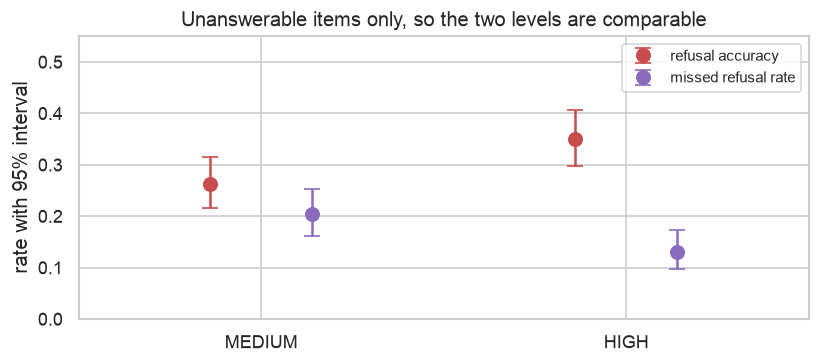

In [11]:
print("ground-truth codes by intensity, unanswerable only")
print(pd.crosstab(unanswerable["ground_truth_label"], unanswerable["intensity"]).to_string())
print()

rows = []
for lvl in ["MEDIUM", "HIGH"]:
    g = unanswerable[unanswerable["intensity"] == lvl]
    n_ref = int(g["refusal_match_correct"].eq(True).sum())
    n_miss = int(g["model_predicted_type"].eq("answer_attempt").sum())
    rows.append({
        "intensity": lvl, "n": len(g),
        "refusal_accuracy": n_ref / len(g), "refusal_ci": wilson(n_ref, len(g)),
        "missed_refusal_rate": n_miss / len(g), "missed_ci": wilson(n_miss, len(g)),
        "info_missing_share": g["model_predicted_type"].eq("REFUSE_INFO_MISSING_IN_CONTEXT").mean(),
    })
inten = pd.DataFrame(rows).set_index("intensity")
print(inten[["n", "refusal_accuracy", "missed_refusal_rate", "info_missing_share"]].round(3).to_string())


def two_prop_z(p1, n1, p2, n2):
    pooled = (p1 * n1 + p2 * n2) / (n1 + n2)
    se = np.sqrt(pooled * (1 - pooled) * (1 / n1 + 1 / n2))
    return (p1 - p2) / se


print()
print("HIGH minus MEDIUM, refusal accuracy:   z = %+.2f"
      % two_prop_z(inten.loc["HIGH", "refusal_accuracy"], 300,
                   inten.loc["MEDIUM", "refusal_accuracy"], 300))
print("HIGH minus MEDIUM, missed refusal rate: z = %+.2f"
      % two_prop_z(inten.loc["HIGH", "missed_refusal_rate"], 300,
                   inten.loc["MEDIUM", "missed_refusal_rate"], 300))

fig, ax = plt.subplots(figsize=(7, 3.2))
x = np.arange(2)
for i, (metric, ci, label, colour) in enumerate([
    ("refusal_accuracy", "refusal_ci", "refusal accuracy", "#c94c4c"),
    ("missed_refusal_rate", "missed_ci", "missed refusal rate", "#8a6bbe"),
]):
    pos = x + (i - 0.5) * 0.28
    vals = inten[metric].values
    lo = np.array([c[0] for c in inten[ci]])
    hi = np.array([c[1] for c in inten[ci]])
    ax.errorbar(pos, vals, yerr=[vals - lo, hi - vals], fmt="o", capsize=5,
                markersize=8, lw=1.5, color=colour, label=label)
ax.set_xticks(x, ["MEDIUM", "HIGH"])
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 0.55)
ax.set_ylabel("rate with 95% interval")
ax.set_title("Unanswerable items only, so the two levels are comparable")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

HIGH intensity is **easier** for the model than MEDIUM, not harder. It refuses correctly more often
(0.350 against 0.263, z = +2.30) and answers when it should not less often (0.130 against 0.203,
z = -2.41). Both are around p = 0.02 unadjusted, and this notebook runs many comparisons, so treat
this as suggestive rather than established.

The reading that fits section 4: a stronger perturbation makes the problem more visible, so the model
declines more readily. It does not improve the model's ability to name the reason, and the share of
refusals going to `INFO_MISSING` is identical at 0.607 for both levels.

Whatever the mechanism, "higher intensity means a harder item" is not what this pilot shows.

## 8. How fine a slice can this pilot support?

`metrics_by_stratum.csv` has one row per language, perturbation class and intensity, and each row
covers 10 items. It is worth seeing what 10 items buys.

In [12]:
print("95% Wilson intervals at the stratum cell size of n=10")
for k in [0, 2, 5, 8, 10]:
    lo, hi = wilson(k, 10)
    print(f"  {k}/10 = {k / 10:.2f}   interval [{lo:.2f}, {hi:.2f}]   width {hi - lo:.2f}")

stratum = metrics_stratum[metrics_stratum["judge_id"] == CONSENSUS]
print()
print(f"{len(stratum)} stratum rows, each covering {int(stratum['n'].min())} items")
pure = ((stratum["num_answerable"] == 0) | (stratum["num_unanswerable"] == 0)).mean()
print(f"share of stratum rows that are pure: {pure:.0%}")
print()
print("metrics_by_stratum.csv for consensus judge:")
print(f"  calibrated_refusal_score is NaN in {stratum['calibrated_refusal_score'].isna().mean():.0%} of rows")
print(f"  answer_accuracy is NaN in           {stratum['answer_accuracy'].isna().mean():.0%} of rows"
      "   (the pure-unanswerable two thirds)")
print(f"  refusal_accuracy is NaN in          {stratum['refusal_accuracy'].isna().mean():.0%} of rows"
      "   (the pure-answerable third)")
print()
print("counts are still real, so the file remains usable for checking design balance:")
print(stratum.groupby("intensity")[["n", "num_answerable", "num_unanswerable"]].sum().to_string())

# the delta baseline must be the english cell in the same stratum, so english
# differenced against itself has to be exactly zero wherever the metric exists.
DELTA_METRICS = ["answer_accuracy", "refusal_accuracy", "false_refusal_rate",
                 "missed_refusal_rate", "calibrated_refusal_score"]
en_stratum = stratum[stratum["language"] == "en"]
print()
print("english self-delta check, must be 0.0 wherever the underlying metric exists:")
for m in DELTA_METRICS:
    vals = en_stratum[f"delta_vs_en_{m}"].dropna()
    worst = vals.abs().max() if len(vals) else np.nan
    print(f"  delta_vs_en_{m:26s} {len(vals):2d} non-null, max |value| = {worst}")
    assert len(vals) == 0 or worst == 0.0, f"english baseline mismatched for {m}"
print("  passed: every stratum row is differenced against its own English cell")

95% Wilson intervals at the stratum cell size of n=10
  0/10 = 0.00   interval [0.00, 0.28]   width 0.28
  2/10 = 0.20   interval [0.06, 0.51]   width 0.45
  5/10 = 0.50   interval [0.24, 0.76]   width 0.53
  8/10 = 0.80   interval [0.49, 0.94]   width 0.45
  10/10 = 1.00   interval [0.72, 1.00]   width 0.28

90 stratum rows, each covering 10 items
share of stratum rows that are pure: 100%

metrics_by_stratum.csv for consensus judge:
  calibrated_refusal_score is NaN in 100% of rows
  answer_accuracy is NaN in           67% of rows   (the pure-unanswerable two thirds)
  refusal_accuracy is NaN in          33% of rows   (the pure-answerable third)

counts are still real, so the file remains usable for checking design balance:
               n  num_answerable  num_unanswerable
intensity                                         
HIGH       300.0             0.0             300.0
LOW        300.0           300.0               0.0
MEDIUM     300.0             0.0             300.0

english s

A stratum cell of 10 items has a 95 percent interval roughly 0.5 wide anywhere in the middle of the
range. Nothing at that granularity separates from anything else. Combined with the fact that 100
percent of stratum rows are pure, the practical rule is: **`metrics_by_stratum.csv` is useful for
spotting data problems and for nothing else in this pilot.** Language-level (n=180) and
perturbation-level (n=150) slices are the finest that support a claim, and even those only
marginally.

Every calibrated score in `metrics_by_stratum.csv` is undefined for this pilot, and the component with
no population is undefined too. Each `delta_vs_en_*` value is the gap versus the English cell with
the same perturbation class and intensity. The cell above checks that English differs from itself by
zero wherever the underlying metric exists. At n=10 per cell those deltas are still far too noisy to
read individually.

## 9. Conclusions

### What the pilot establishes

1. **The judges are reliable for classification and unreliable for quality.** Cohen kappa 0.984 to
   0.993 and Fleiss 0.990 on refusal codes, against Spearman 0.67 to 0.70 on the 1 to 5 quality
   score. Consensus classification labels can be pooled without concern. Anything gated on the
   quality threshold, which means `answer_accuracy` and therefore `calibrated_refusal_score`, carries
   judge noise worth up to 0.058 in the final score.

2. **The model collapses its refusal vocabulary onto one code.** 61 percent of predictions on
   unanswerable items are `REFUSE_INFO_MISSING_IN_CONTEXT`, against a 17 percent ground-truth
   prevalence. `REFUSE_GRANULARITY_MISMATCH` and `REFUSE_OTHER` are never emitted once in 900 items.
   This is the dominant fact about the run and it contaminates every `refusal_accuracy` figure
   downstream.

3. **False-premise framing causes heavy over-refusal on answerable questions.** Answerable items in
   the FalsePremise class score 0.220 answer accuracy with a 0.660 false refusal rate, against 0.740
   to 0.760 accuracy for Contradiction and Ambiguity. This one is measured on the answerable side,
   so it is not an artefact of the label collapse, and it is the strongest usable result in the pilot.

4. **The model detects unanswerability far better than it explains it.** It declines on 500 of 600
   unanswerable items but names the right reason on only 184.

### What the pilot does not establish

5. **The language ranking.** English leads on every point estimate and the direction is consistent,
   but every non-English interval overlaps English, the largest single-component gap reaches only
   z = 1.85, and judge choice alone moves the calibrated score by up to 0.058 against a largest
   language gap of 0.100. Report as directional. The *shape* is more trustworthy than the size: the
   gap sits on the answerable side as over-refusal, with missed refusal rates flat or lower outside
   English.

6. **The perturbation difficulty ranking on the refusal side.** MissingInfo at 0.84 and Granularity
   at 0.00 reflect which codes the model owns, not which perturbations are hard. Do not report this
   ranking as difficulty.

7. **Any monotonic intensity story.** LOW is the answerable control and is not on the same scale as
   MEDIUM and HIGH. On the comparison that is valid, MEDIUM against HIGH within unanswerable items,
   HIGH is the *easier* level (z = +2.30 on refusal accuracy, z = -2.41 on missed refusals),
   unadjusted for multiple comparisons.

8. **Anything at stratum granularity.** 10 items per cell gives intervals about 0.5 wide, and all 90
   stratum rows are pure so they carry no calibrated score at all.

### Recommended changes before scaling up

9. **Break the answerability and intensity confound.** Put answerable controls at every intensity, or
   stop calling the answerable stratum an intensity level. As built, no intensity conclusion is
   reachable.

10. **Report `answer_accuracy` and `refusal_accuracy` separately and retire the pooled calibrated
    score,** or at minimum publish it only alongside both components. Averaging a
    judge-noise-dominated metric with a label-collapse-dominated metric produces a number whose
    movements cannot be attributed.

11. **Add a partial-credit refusal metric.** Exact 7-way code match scores a correctly-detected
    refusal as a total failure whenever the code is wrong, which is 316 of 500 detections here. A
    detection metric plus a conditional typing metric would separate the two skills that are
    currently entangled.

12. **Raise n before drawing language conclusions.** At 60 answerable items per language, gaps of the
    observed size are not resolvable. The observed English against Polish answer accuracy gap would
    need roughly 4 times the items to reach conventional significance.